# 04 · Sequence Models: Embeddings, RNNs and LSTMs

**Contents**

1. Sequences and why MLPs don't fit
2. From text to vectors: tokens, one-hot, embeddings
3. The recurrent neural network (RNN)
4. Backpropagation through time and vanishing gradients (derivation)
5. The LSTM, and why its gradient survives
6. The GRU
7. Practicalities: padding, masking, many-to-one, clipping
8. Experiment: how far back can an RNN and an LSTM remember?
9. Limits of recurrence → attention

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0); torch.manual_seed(0)

## 1. Sequences and why MLPs don't fit

Text, audio, time series and event logs are **sequences** $\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_T$. The order matters ("not good, bad" ≠ "not bad, good"), and the length $T$ varies. An MLP needs a fixed-size input and treats every position independently: it would need separate weights for "word at position 3" and "word at position 30", even though a word means the same thing wherever it appears.

A recurrent network reads the sequence one step at a time, with the **same weights at every step**, and keeps a **hidden state** $\mathbf{h}_t$ that summarises what it has read so far. This is weight sharing across time, just as a CNN shares weights across space.

## 2. From text to vectors

1. **Tokenise**: split the text into tokens (words, sub-words, characters).
2. **Index**: map each token to an integer in a vocabulary of size $|V|$ (plus special tokens: `<PAD>`, `<UNK>` for unknown words, `<START>`).
3. **Embed**: map each index to a dense vector $\mathbf{x}_t = \mathbf{E}[\text{index}_t] \in\mathbb{R}^d$, where $\mathbf{E}\in\mathbb{R}^{|V|\times d}$ is a learned **embedding matrix** (`nn.Embedding`).

**An embedding layer is a linear layer on one-hot vectors.** If $\mathbf{o}_k\in\{0,1\}^{|V|}$ is the one-hot vector of token $k$, then $\mathbf{o}_k^\top\mathbf{E} = \mathbf{E}_{k,:}$ (the product just selects row $k$). So "looking up a row" is exactly a dense layer without bias applied to the one-hot encoding, implemented without the huge sparse multiplication. It is trained by backprop like any other weight: only the rows of the tokens present in the batch receive gradient.

Why dense embeddings: one-hot vectors are huge ($|V|$ is often $10^4$–$10^5$) and all equally far apart ("good" is as far from "great" as from "banana"). Learned embeddings are small ($d\sim 32$–$1024$) and place tokens used in similar contexts close together (notebook 06).

In [2]:
V, d = 10, 4
E = nn.Embedding(V, d)
idx = torch.tensor([3, 7, 3])
onehot = F.one_hot(idx, V).float()
print("lookup E[idx]        :\n", E(idx).detach().numpy().round(3))
print("one-hot @ E.weight   :\n", (onehot @ E.weight).detach().numpy().round(3))

lookup E[idx]        :
 [[ 0.12   1.238  1.117 -0.247]
 [-0.174 -0.679  0.938  0.489]
 [ 0.12   1.238  1.117 -0.247]]
one-hot @ E.weight   :
 [[ 0.12   1.238  1.117 -0.247]
 [-0.174 -0.679  0.938  0.489]
 [ 0.12   1.238  1.117 -0.247]]


## 3. The recurrent neural network (RNN)

With row-vector notation as in the previous notebooks ($\mathbf{x}_t\in\mathbb{R}^{1\times d}$, $\mathbf{h}_t\in\mathbb{R}^{1\times d_h}$):

$$
\mathbf{h}_t = \tanh\big(\mathbf{x}_t\mathbf{W}_x + \mathbf{h}_{t-1}\mathbf{W}_h + \mathbf{b}\big), \qquad \mathbf{h}_0 = \mathbf{0},
$$

with parameters $\boldsymbol{\theta} = \{\mathbf{W}_x\in\mathbb{R}^{d\times d_h}, \mathbf{W}_h\in\mathbb{R}^{d_h\times d_h}, \mathbf{b}\}$ **shared by all time steps**. Unrolled over time, it is a very deep feed-forward network (one layer per time step) whose layers share their weights.

**Architectures by input/output:**

| Pattern | Example | Output |
|---|---|---|
| many-to-one | sentiment of a review (LSTM lab) | a head on the last state $\mathbf{h}_T$ (or on a pooled summary) |
| many-to-many (aligned) | part-of-speech tagging, per-step forecasting | a head on every $\mathbf{h}_t$ |
| sequence-to-sequence | translation | encoder RNN → decoder RNN |
| language model | next-token prediction | softmax over $\lvert V\rvert$ at every step, trained with cross-entropy |

## 4. Backpropagation through time and vanishing gradients

**BPTT** is ordinary backprop on the unrolled graph. Because $\mathbf{W}_h$ is used at every step, its gradient is the **sum** over time steps of the per-step contributions (shared weights → gradients add up, as in notebook 01).

The gradient that reaches an early state is a product of Jacobians. With $\mathbf{a}_t$ the pre-activation, $\mathbf{h}_t = \tanh(\mathbf{a}_t)$:

$$
\frac{\partial\mathbf{h}_t}{\partial\mathbf{h}_{t-1}} = \mathrm{diag}\big(1 - \mathbf{h}_t^2\big)\,\mathbf{W}_h^\top
\qquad\Rightarrow\qquad
\frac{\partial J}{\partial\mathbf{h}_k} = \frac{\partial J}{\partial\mathbf{h}_T}\prod_{t=k+1}^{T}\mathrm{diag}\big(1-\mathbf{h}_t^2\big)\mathbf{W}_h^\top
$$

(the order of the factors follows the chain rule). Take norms: $\lVert\mathrm{diag}(1-\mathbf{h}_t^2)\rVert\le1$, since $\tanh'\le1$, so

$$
\Big\lVert\frac{\partial J}{\partial\mathbf{h}_k}\Big\rVert \le \Big\lVert\frac{\partial J}{\partial\mathbf{h}_T}\Big\rVert\;\lVert\mathbf{W}_h\rVert^{\,T-k}.
$$

If $\lVert\mathbf{W}_h\rVert < 1$ the signal from $T-k$ steps back shrinks **exponentially**: **vanishing gradients**. The network cannot learn that the label depends on something 50 steps ago. If the largest singular value is $>1$ (and the units are not saturated), the product can blow up: **exploding gradients**, fixed by gradient clipping. Vanishing is the harder problem, and it is what the LSTM solves.

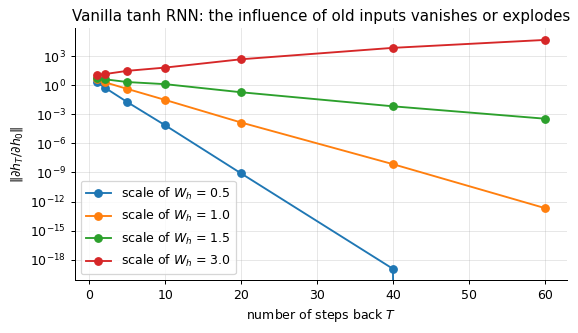

In [3]:
# Norm of d h_T / d h_0 for a random tanh RNN, as a function of T and of the scale of W_h
def jac_norm(T, scale, dh=32, seed=0):
    g = torch.Generator().manual_seed(seed)
    Wh = torch.randn(dh, dh, generator=g) * scale / np.sqrt(dh)     # spectral radius ~ scale
    Wx = torch.randn(8, dh, generator=g) / np.sqrt(8)
    xs = torch.randn(T, 1, 8, generator=g)                            # random inputs x_1..x_T
    def run(h):
        for t in range(T):
            h = torch.tanh(xs[t] @ Wx + h @ Wh)
        return h
    return torch.autograd.functional.jacobian(run, torch.zeros(1, dh)).norm().item()

Ts = [1, 2, 5, 10, 20, 40, 60]
plt.figure(figsize=(6.5, 3.8))
for scale in [0.5, 1.0, 1.5, 3.0]:
    plt.plot(Ts, [jac_norm(T, scale) for T in Ts], "o-", label=f"scale of $W_h$ = {scale}")
plt.yscale("log"); plt.xlabel("number of steps back $T$"); plt.ylabel(r"$\|\partial h_T/\partial h_0\|$")
plt.title("Vanilla tanh RNN: the influence of old inputs vanishes or explodes"); plt.legend(); plt.tight_layout(); plt.show()

Both failure modes appear. With small recurrent weights the influence of $\mathbf{h}_0$ on $\mathbf{h}_T$ **vanishes** exponentially (for scale 0.5 it underflows to 0 before $T=60$). With large weights it **explodes** exponentially. Saturation of the tanh units ($1-h_t^2\approx0$) slows the explosion but doesn't stop it here. Only a narrow range in between keeps the signal roughly constant, and training cannot be expected to stay there. That is why gating (next section) and gradient clipping are needed.

## 5. The LSTM

The **Long Short-Term Memory** (Hochreiter & Schmidhuber, 1997) adds a **cell state** $\mathbf{c}_t$, a memory that is updated **additively** and controlled by **gates**, which are sigmoids in $(0,1)$ that act as soft switches. With $[\mathbf{h}_{t-1}, \mathbf{x}_t]$ the concatenation:

$$
\begin{aligned}
\mathbf{f}_t &= \sigma\big([\mathbf{h}_{t-1},\mathbf{x}_t]\mathbf{W}_f + \mathbf{b}_f\big) && \text{forget gate: how much old memory to keep}\\
\mathbf{i}_t &= \sigma\big([\mathbf{h}_{t-1},\mathbf{x}_t]\mathbf{W}_i + \mathbf{b}_i\big) && \text{input gate: how much new content to write}\\
\tilde{\mathbf{c}}_t &= \tanh\big([\mathbf{h}_{t-1},\mathbf{x}_t]\mathbf{W}_c + \mathbf{b}_c\big) && \text{candidate content}\\
\mathbf{c}_t &= \mathbf{f}_t\odot\mathbf{c}_{t-1} + \mathbf{i}_t\odot\tilde{\mathbf{c}}_t && \text{memory update (additive)}\\
\mathbf{o}_t &= \sigma\big([\mathbf{h}_{t-1},\mathbf{x}_t]\mathbf{W}_o + \mathbf{b}_o\big) && \text{output gate: how much memory to expose}\\
\mathbf{h}_t &= \mathbf{o}_t\odot\tanh(\mathbf{c}_t)
\end{aligned}
$$

**Why the gradient survives.** Along the memory path,
$$
\frac{\partial\mathbf{c}_t}{\partial\mathbf{c}_{t-1}} = \mathrm{diag}(\mathbf{f}_t) \quad(\text{plus terms through the gates}),
\qquad
\frac{\partial\mathbf{c}_T}{\partial\mathbf{c}_k}\approx\prod_{t=k+1}^T\mathrm{diag}(\mathbf{f}_t).
$$
There is no weight matrix and no squashing derivative in this product, only the forget gates. When the network wants to remember (it has learned $\mathbf{f}_t\approx1$), the gradient flows back almost unchanged over many steps. This is the same idea as the residual connection $\mathbf{y} = \mathbf{x} + F(\mathbf{x})$ in notebook 03: an additive path with a near-identity Jacobian. (Practical tip: initialise the forget-gate bias to a positive value, so the LSTM starts out remembering; section 8 shows how much this matters.)

**Parameters**: four gate blocks, each with a $(d_h + d)\times d_h$ matrix and a bias, so $4\big(d_h(d_h + d) + d_h\big)$. (PyTorch stores two bias vectors per gate, giving $4d_h$ more.)

## 6. The GRU

The **Gated Recurrent Unit** (Cho et al., 2014) merges the cell and hidden state and uses two gates:
$$
\mathbf{z}_t = \sigma(\cdot),\quad \mathbf{r}_t = \sigma(\cdot),\quad
\tilde{\mathbf{h}}_t = \tanh\big([\mathbf{r}_t\odot\mathbf{h}_{t-1}, \mathbf{x}_t]\mathbf{W} + \mathbf{b}\big),\quad
\mathbf{h}_t = (1-\mathbf{z}_t)\odot\mathbf{h}_{t-1} + \mathbf{z}_t\odot\tilde{\mathbf{h}}_t .
$$
It has the same additive "keep or overwrite" update with ¾ of the LSTM's parameters. In practice the two perform similarly; the GRU is a bit faster.

## 7. Practicalities

- **Padding and truncation.** Batches need equal lengths: pad short sequences with `<PAD>` (index 0) and truncate long ones (the LSTM lab keeps 100 tokens). Cutting reviews at 100 words loses information: sentiment is often at the end.
- **Masking / packing.** Pad tokens should not influence the result. Use `nn.utils.rnn.pack_padded_sequence`, or at least take the hidden state at each sequence's **true** last position, and mask pads out of losses and pooling. Otherwise, left-pad so the real tokens come last.
- **Many-to-one heads.** The last hidden state $\mathbf{h}_T$ must summarise the whole sequence, a bottleneck for long inputs. Alternatives: mean/max-pool all $\mathbf{h}_t$, or attention pooling (notebook 05).
- **Bidirectional RNNs** run one RNN left-to-right and another right-to-left and concatenate their states. Fine for classification, not for generation (the future is unknown).
- **Stacking**: 2–3 layers of LSTM (`num_layers`), with dropout between layers.
- **Gradient clipping** is standard for RNNs (`clip_grad_norm_`, notebook 02).

## 8. Experiment: how far back can an RNN and an LSTM remember?

Task: sequences of $T$ random tokens from a vocabulary of 20. The label is 1 if the **first** token is one of tokens 0–9; every later token is noise. The model reads the whole sequence and classifies from its **last** hidden state, so it must carry one bit of information across $T-1$ irrelevant steps. Chance is 50 %. Every training step draws a fresh batch (unlimited data, so we measure memory, not overfitting). Every model gets the same budget of 800 steps.

We compare a vanilla RNN, an LSTM with PyTorch's default initialisation, and an LSTM whose **forget-gate bias starts at 5** ($f_t\approx\sigma(5)\approx0.993$ at the start). Section 5 predicts that the gradient through the memory is $\prod_t f_t$. With the default init $f_t\approx0.5$ and $0.5^{50}\approx10^{-15}$, while $0.993^{100}\approx0.5$.

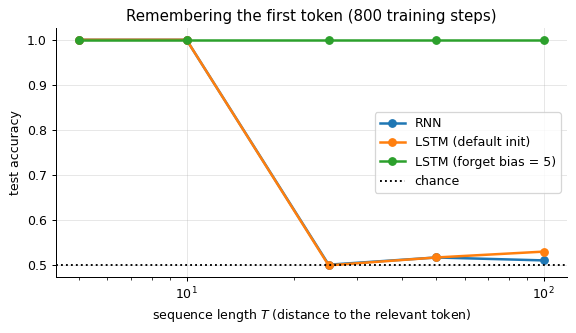

                     RNN: T=5: 1.00  T=10: 1.00  T=25: 0.50  T=50: 0.52  T=100: 0.51
     LSTM (default init): T=5: 1.00  T=10: 1.00  T=25: 0.50  T=50: 0.52  T=100: 0.53
  LSTM (forget bias = 5): T=5: 1.00  T=10: 1.00  T=25: 1.00  T=50: 1.00  T=100: 1.00


In [4]:
class SeqClassifier(nn.Module):
    def __init__(self, cell, V=20, d=16, dh=32, forget_bias=None):
        super().__init__()
        self.emb = nn.Embedding(V, d)
        self.rnn = nn.LSTM(d, dh, batch_first=True) if cell == "LSTM" else nn.RNN(d, dh, batch_first=True)
        if forget_bias is not None:              # PyTorch gate order: input, forget, cell, output
            with torch.no_grad():
                self.rnn.bias_ih_l0[dh:2 * dh].fill_(forget_bias); self.rnn.bias_hh_l0[dh:2 * dh].fill_(0.0)
        self.head = nn.Linear(dh, 1)
    def forward(self, tokens):                   # tokens: (B, T)
        out, _ = self.rnn(self.emb(tokens))      # out: (B, T, dh)
        return self.head(out[:, -1]).squeeze(-1) # many-to-one: last hidden state -> logit

def batch(n, T, g):
    x = torch.randint(0, 20, (n, T), generator=g)
    return x, (x[:, 0] < 10).float()

def train_and_test(cell, T, forget_bias=None, steps=800, seed=0):
    torch.manual_seed(seed); g = torch.Generator().manual_seed(seed)
    model = SeqClassifier(cell, forget_bias=forget_bias); opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for _ in range(steps):
        xb, yb = batch(64, T, g)
        opt.zero_grad(); F.binary_cross_entropy_with_logits(model(xb), yb).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    Xte, yte = batch(2000, T, torch.Generator().manual_seed(999))
    with torch.no_grad():
        return ((model(Xte) > 0).float() == yte).float().mean().item()

torch.set_num_threads(4)
lengths = [5, 10, 25, 50, 100]
configs = {"RNN": ("RNN", None), "LSTM (default init)": ("LSTM", None), "LSTM (forget bias = 5)": ("LSTM", 5.0)}
res = {name: [train_and_test(cell, T, fb) for T in lengths] for name, (cell, fb) in configs.items()}
plt.figure(figsize=(6.5, 3.8))
for name, accs in res.items(): plt.plot(lengths, accs, "o-", lw=2, label=name)
plt.axhline(0.5, color="k", ls=":", label="chance")
plt.xscale("log"); plt.xlabel("sequence length $T$ (distance to the relevant token)"); plt.ylabel("test accuracy")
plt.title("Remembering the first token (800 training steps)"); plt.legend(); plt.tight_layout(); plt.show()
for name, accs in res.items(): print(f"{name:>24}:", "  ".join(f"T={T}: {a:.2f}" for T, a in zip(lengths, accs)))

With the same 800 steps, the vanilla RNN and the default-initialised LSTM both drop to chance once the relevant token is 25 or more steps back. The LSTM whose forget gates start **open** solves every length up to 100. That is section 5 made concrete: the LSTM *can* carry gradient over long ranges, but only if $\prod_t f_t$ is not tiny. With the default init ($f_t\approx0.5$) it is as badly off as the RNN until it slowly learns to open the gate, which takes more than this budget. With the gate starting near 1, the gradient reaches the first token from step one.

Practical lessons: initialise LSTM forget-gate biases to a positive value (1 is the classic recommendation; larger for very long dependencies), and remember that "the architecture can represent it" is not the same as "gradient descent will find it quickly".

## 9. Limits of recurrence → attention

Even LSTMs have two structural limits:
1. **Bottleneck**: everything must pass through a fixed-size state; in a many-to-one or encoder–decoder model, early information must survive many updates.
2. **Sequential computation**: $\mathbf{h}_t$ needs $\mathbf{h}_{t-1}$, so the $T$ steps can't be computed in parallel. Training on long sequences is slow on GPUs.

**Attention** lets every position look directly at every other position, with a path of length 1 between any two tokens, all in parallel. Transformers (notebook 05) are built from attention alone and have largely replaced RNNs for text.

## Summary

- Text → tokens → indices → embeddings; an embedding is a linear layer on one-hot vectors, learned by backprop.
- RNN: $\mathbf{h}_t = \tanh(\mathbf{x}_t\mathbf{W}_x + \mathbf{h}_{t-1}\mathbf{W}_h + \mathbf{b})$, weights shared across time; trained by BPTT.
- Gradients to old steps are products of $\mathrm{diag}(1-\mathbf{h}^2)\mathbf{W}_h^\top$, which vanish (or explode) exponentially with distance.
- LSTM/GRU: gated, **additive** memory; $\partial\mathbf{c}_t/\partial\mathbf{c}_{t-1}\approx\mathrm{diag}(\mathbf{f}_t)$ lets gradients flow over long ranges (same idea as residual connections).
- In practice: pad/truncate and mask, pick a sensible many-to-one head, clip gradients.
- Recurrence is sequential and has a state bottleneck; attention removes both.